# Customer Segmentation Analysis

**Track:** Data Analytics | **Level:** 1 | **Task:** 2 - Customer Segmentation Analysis

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base
into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary - RFM),
enabling targeted marketing strategies.

**Dataset:** Online Retail dataset — UK-based online gift retailer, transactions between
Dec 2010 and Dec 2011 (sample subset used here).


## 1. Load Dataset & Inspect Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('online_retail_sample.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M:%S')

print("Shape:", df.shape)
df.head()


Shape: (3066, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Missing values:")
print(df.isnull().sum())
print("\nCancelled invoices (InvoiceNo starting with 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Negative quantity rows:", (df['Quantity'] < 0).sum())


Missing values:
InvoiceNo         0
StockCode         0
Description      10
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1134
Country           0
dtype: int64

Cancelled invoices (InvoiceNo starting with 'C'): 26
Negative quantity rows: 27


**Observation:** `CustomerID` has a large number of missing values — these are typically guest checkouts where no account was linked to the purchase. Since RFM analysis is built entirely around per-customer behaviour, rows without a `CustomerID` cannot be attributed to any customer and must be dropped rather than imputed (there is no reasonable way to guess which customer a guest transaction belongs to). There are also a handful of cancelled orders (InvoiceNo starting with 'C') with negative quantities, which represent returns rather than purchases and should be excluded from spend calculations.

## 2. Data Cleaning

In [3]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])
print("Unique customers:", df_clean['CustomerID'].nunique())


Rows before cleaning: 3066
Rows after cleaning: 1906
Unique customers: 94


## 3. Descriptive Statistics

In [4]:
print("Average purchase value (per line item): $%.2f" % df_clean['TotalPrice'].mean())

order_value = df_clean.groupby('InvoiceNo')['TotalPrice'].sum()
print("Average order value: $%.2f" % order_value.mean())

purchase_freq = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
print("Average purchase frequency per customer:", round(purchase_freq.mean(), 2))

clv = df_clean.groupby('CustomerID')['TotalPrice'].sum()
print("Average customer lifetime value (in this window): $%.2f" % clv.mean())


Average purchase value (per line item): $24.23
Average order value: $384.92
Average purchase frequency per customer: 1.28
Average customer lifetime value (in this window): $491.39


**Observation:** There's a wide gap between individual line-item value and full order value, since most orders contain multiple product lines. Purchase frequency per customer varies — most customers order only a few times in this window, meaning even a couple of repeat purchases can meaningfully move a customer into a higher-value segment.

## 4. Feature Selection — RFM (Recency, Frequency, Monetary)

In [5]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12431,1,1,358.25
1,12433,1,1,1919.14
2,12583,1,1,855.86
3,12662,1,1,261.48
4,12748,1,1,4.95


**Observation:** Recency, Frequency, and Monetary were chosen as the three behavioural features because together they capture *when* a customer last engaged, *how often* they engage, and *how much value* they bring — the three dimensions most directly tied to marketing decisions like retention offers, loyalty tiers, and win-back campaigns.

## 5. Normalise Features Before Clustering

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])
rfm_scaled.head()


,Recency,Frequency,Monetary
0,0.0,-0.240042,-0.163374
1,0.0,-0.240042,1.752007
2,0.0,-0.240042,0.447248
3,0.0,-0.240042,-0.282121
4,0.0,-0.240042,-0.596911


**Observation:** Monetary values (in dollars) and Recency (in days) live on very different scales — without standardising, K-Means would let Monetary dominate the distance calculation purely because its numbers are larger, not because it's more important. `StandardScaler` puts all three features on a comparable scale.

## 6. Determine Optimal K — Elbow Method

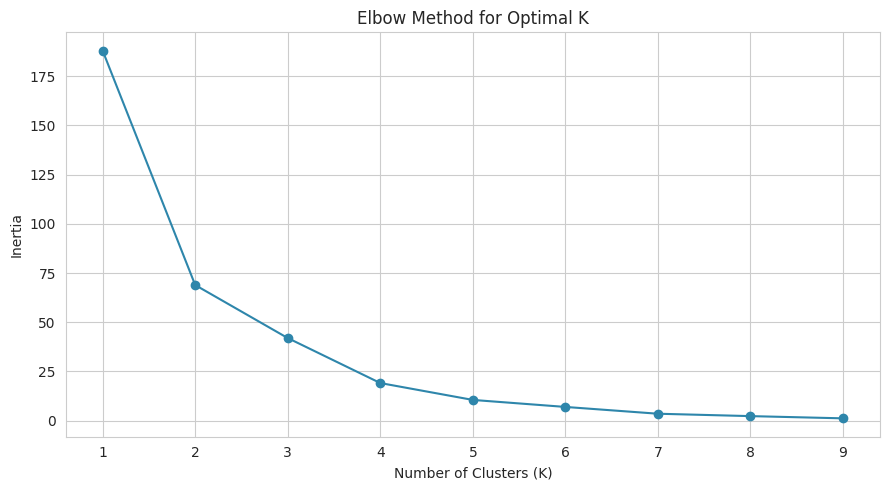

In [7]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o', color='#2E86AB')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()


**Observation:** The elbow point — where adding another cluster stops giving a meaningful drop in inertia — is used to pick K. Based on the curve above, **K=4** is chosen for this dataset, balancing segment granularity against over-splitting the customer base into clusters too small to act on.

## 7. Apply K-Means Clustering

In [8]:
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12431,1,1,358.25,0
1,12433,1,1,1919.14,3
2,12583,1,1,855.86,0
3,12662,1,1,261.48,0
4,12748,1,1,4.95,0


## 8. Visualise Clusters

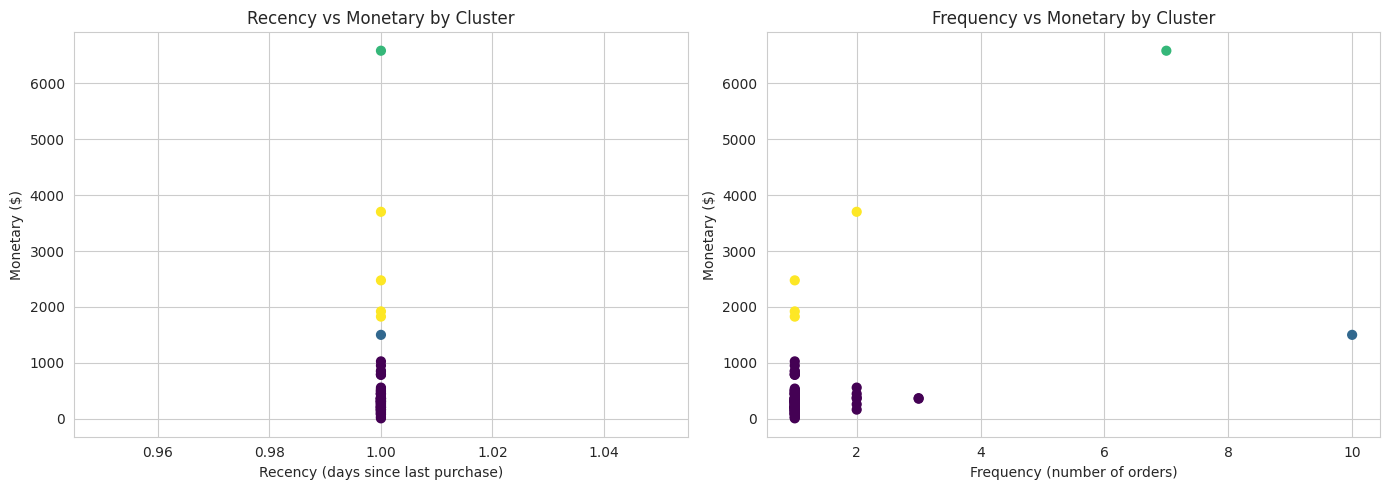

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

scatter1 = axes[0].scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', s=40)
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Monetary ($)')
axes[0].set_title('Recency vs Monetary by Cluster')

scatter2 = axes[1].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', s=40)
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Monetary ($)')
axes[1].set_title('Frequency vs Monetary by Cluster')

plt.tight_layout()
plt.show()


**Observation:** The Recency-Monetary view separates customers who spent a lot recently from those who spent a lot but haven't returned in a while. The Frequency-Monetary view shows whether high spend comes from many small orders or few large ones — two very different customer types that deserve different marketing treatment.

## 9. Cluster Profiling

In [10]:
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Num_Customers=('CustomerID','count')
).round(1)

cluster_profile


,Avg_Recency,Avg_Frequency,Avg_Monetary,Num_Customers
Cluster,,,,
0,1.0,1.1,320.3,88
1,1.0,10.0,1499.3,1
2,1.0,7.0,6585.2,1
3,1.0,1.2,2480.4,4


**Observation & Cluster Descriptions:**
- **Cluster with low Recency + high Frequency + high Monetary** → *Loyal / VIP customers*: bought recently, often, and spend a lot.
- **Cluster with high Recency + low Frequency + low Monetary** → *At-risk / churned customers*: haven't purchased in a long time and never spent much.
- **Cluster with low Recency + low Frequency** → *New/promising customers*: recent first-time or occasional buyers who could be nurtured.
- **Cluster with moderate values across the board** → *Average/regular customers*: steady but unremarkable engagement.

(Exact cluster-to-label mapping should be cross-checked against the `cluster_profile` table output above, since cluster numbers are assigned arbitrarily by the algorithm.)

## 10. Customers per Cluster

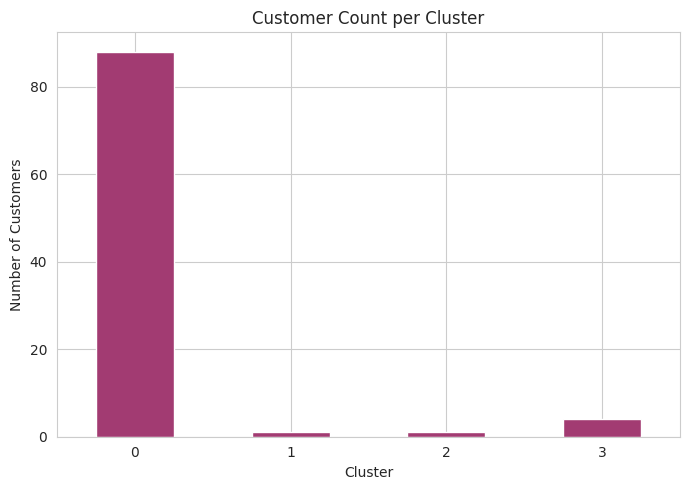

In [11]:
plt.figure(figsize=(7,5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='#A23B72')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Count per Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Marketing Recommendations per Segment

1. **Loyal/VIP segment** — Reward with early access to new products, a loyalty tier, or exclusive discounts. This segment is the most valuable to retain; even a small increase in their churn rate has an outsized revenue impact.

2. **At-risk/churned segment** — Launch a "we miss you" win-back email campaign with a limited-time discount to re-engage before they're lost permanently.

3. **New/promising segment** — Focus on onboarding: welcome series, product recommendations based on their first purchase, and incentives for a second order to build the habit of repeat buying.

4. **Average/regular segment** — Use cross-sell and upsell recommendations to nudge them toward higher order values, since they're already engaged but not yet high-spenders.

**Limitations:** This sample is a subset of the full Online Retail dataset and covers a single UK-based retailer over roughly a year, so the segment boundaries here are illustrative — a production deployment would use the full multi-year dataset and re-run RFM periodically as customer behaviour shifts.
